# Side-by-side reconstruction comparisons (DiffPIR vs. RD)

Loads precomputed posterior means and stds from `metrics_csv_phantom_analysis*` directories and shows ground truth + each method's mean, std, and absolute error contour-overlaid on the flux surfaces. Mean/phantom panels use `viridis`; std and `|gt-mean|` panels use `inferno`. Tweak `idx_to_be_plotted` and `noise_idx` in each cell to inspect different samples.

In [175]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import colors as mcolors
from matplotlib import cm

from reaction_diffusion.routines.tomo_fusion.tools import plotting_fcts as tomo_plots

H, W = 120, 40
SAMPLES_DIR = Path("/home/fusiontomo/Repos/diffusion_tomography/test_set_sxr_samples")
GROUND_TRUTH = np.load(SAMPLES_DIR / "sxr_samples_with_background_coarse.npy")
PSI          = np.load(SAMPLES_DIR / "psis_coarse.npy")

DIFF_DIR   = Path("metrics_csv_phantom_analysis")
RD_DIR     = Path("metrics_csv_phantom_analysis_rd")
DIFFRD_DIR = Path("metrics_csv_phantom_analysis_diffrd_correct_rdparams")
EPS_OUT    = Path("results_images/diffpir_vs_rd")
EPS_OUT.mkdir(parents=True, exist_ok=True)


# ---------- colorbar helpers ----------

def _fmt_tick(t):
    """Format a tick value: 2 decimal places, trailing zeros stripped."""
    return f"${f'{t:.2f}'.rstrip('0').rstrip('.')}$"


def _default_latex_labels(ticks):
    return [_fmt_tick(t) for t in ticks]


def _resolve(ticks, ticklabels, vmax):
    """Return (ticks, ticklabels) defaulting to [0, vmax/2, vmax]."""
    if ticks is None:
        ticks = [0.0, vmax / 2.0, vmax]
    if ticklabels is None:
        ticklabels = _default_latex_labels(ticks)
    return ticks, ticklabels


def _attach_cbar(fig, ax, cmap, vmax, ticks, ticklabels, fontsize):
    """Attach a vertical colorbar to *ax*, stealing space from it."""
    cbar = fig.colorbar(
        cm.ScalarMappable(norm=mcolors.Normalize(vmin=0, vmax=vmax), cmap=cmap),
        ax=ax, fraction=0.08, pad=0.03,
    )
    cbar.set_ticks(ticks)
    cbar.set_ticklabels(ticklabels, fontsize=fontsize)


def _panel(ax, img, psi, cmap, title, vmax=None):
    tomo_plots.plot_profile(img, tcv_plot_clip=True, contour_image=psi,
                            cmap=cmap, ax=ax, contour_color="w", vmax=vmax,
                            aspect=None, lcfs_width=1, lwidth=0.2)
    ax.set_title(title)


# ---------- interactive plotting ----------

def plot_two_methods(gt, psi, m1, m1_name, m1_psnr,
                     m2, m2_name, m2_psnr, suptitle,
                     viridis_ticks=None,  viridis_ticklabels=None,
                     m1_std_ticks=None,   m1_std_ticklabels=None,
                     m2_std_ticks=None,   m2_std_ticklabels=None,
                     m1_err_ticks=None,   m1_err_ticklabels=None,
                     m2_err_ticks=None,   m2_err_ticklabels=None,
                     cbar_fontsize=8):
    """m1, m2 are dicts with keys 'mean' and 'std'.

    Each of the 7 panels gets its own colorbar matching what save_diffpir_vs_rd_panels saves.
    Viridis colorbars share ticks (viridis_ticks/viridis_ticklabels, range fixed to [0, 1]).
    Std and error colorbars are independent; auto-derived from each panel's data range.
    """
    err1 = np.abs(gt - m1["mean"])
    err2 = np.abs(gt - m2["mean"])
    vmax_mean = float(gt.max())

    _vir_t, _vir_l = _resolve(viridis_ticks, viridis_ticklabels, 1.0)
    if viridis_ticks is None:
        _vir_t = [0.0, 0.5, 1.0]
        _vir_l = _default_latex_labels(_vir_t) if viridis_ticklabels is None else viridis_ticklabels

    _m1s_t, _m1s_l = _resolve(m1_std_ticks, m1_std_ticklabels, float(m1["std"].max()))
    _m2s_t, _m2s_l = _resolve(m2_std_ticks, m2_std_ticklabels, float(m2["std"].max()))
    _m1e_t, _m1e_l = _resolve(m1_err_ticks, m1_err_ticklabels, float(err1.max()))
    _m2e_t, _m2e_l = _resolve(m2_err_ticks, m2_err_ticklabels, float(err2.max()))

    fig, axes = plt.subplots(1, 7, figsize=(2.4 * 7, 3.5))

    _panel(axes[0], gt,         psi, "viridis", "phantom",                              vmax=vmax_mean)
    _panel(axes[1], m1["mean"], psi, "viridis", f"{m1_name} mean\npsnr={m1_psnr:.2f}", vmax=vmax_mean)
    _panel(axes[2], m2["mean"], psi, "viridis", f"{m2_name} mean\npsnr={m2_psnr:.2f}", vmax=vmax_mean)
    _panel(axes[3], m1["std"],  psi, "inferno", f"{m1_name} std")
    _panel(axes[4], err1,       psi, "gray",    f"{m1_name} |gt - mean|")
    _panel(axes[5], m2["std"],  psi, "inferno", f"{m2_name} std")
    _panel(axes[6], err2,       psi, "gray",    f"{m2_name} |gt - mean|")

    _attach_cbar(fig, axes[0], "viridis", 1.0,                    _vir_t, _vir_l, cbar_fontsize)
    _attach_cbar(fig, axes[1], "viridis", 1.0,                    _vir_t, _vir_l, cbar_fontsize)
    _attach_cbar(fig, axes[2], "viridis", 1.0,                    _vir_t, _vir_l, cbar_fontsize)
    _attach_cbar(fig, axes[3], "inferno", float(m1["std"].max()), _m1s_t, _m1s_l, cbar_fontsize)
    _attach_cbar(fig, axes[4], "gray",    float(err1.max()),      _m1e_t, _m1e_l, cbar_fontsize)
    _attach_cbar(fig, axes[5], "inferno", float(m2["std"].max()), _m2s_t, _m2s_l, cbar_fontsize)
    _attach_cbar(fig, axes[6], "gray",    float(err2.max()),      _m2e_t, _m2e_l, cbar_fontsize)

    fig.suptitle(suptitle)
    plt.tight_layout()
    plt.show()


def plot_diffpir_vs_rd(diag, noise, idx, diff_suffix="", rd_suffix="",
                       viridis_ticks=None,   viridis_ticklabels=None,
                       diff_std_ticks=None,  diff_std_ticklabels=None,
                       rd_std_ticks=None,    rd_std_ticklabels=None,
                       diff_err_ticks=None,  diff_err_ticklabels=None,
                       rd_err_ticks=None,    rd_err_ticklabels=None,
                       cbar_fontsize=8):
    diff_means = np.load(DIFF_DIR / f"post_means_{diag}{diff_suffix}_{noise}_false.npy")[idx].reshape(H, W)
    diff_stds  = np.load(DIFF_DIR / f"post_stds_{diag}{diff_suffix}_{noise}_false.npy")[idx].reshape(H, W)
    rd_means   = np.load(RD_DIR   / f"post_means_{diag}{rd_suffix}_{noise}_false.npy")[idx].reshape(H, W)
    rd_stds    = np.load(RD_DIR   / f"post_stds_{diag}{rd_suffix}_{noise}_false.npy")[idx].reshape(H, W)

    diff_metrics = pd.read_csv(DIFF_DIR / f"metrics_diffusion_{diag}{diff_suffix}_{noise}_false.csv")
    rd_metrics   = pd.read_csv(RD_DIR   / f"metrics_rd_{diag}{rd_suffix}_{noise}_false.csv")

    plot_two_methods(
        gt=GROUND_TRUTH[idx], psi=PSI[idx],
        m1={"mean": diff_means, "std": diff_stds}, m1_name="DiffPIR",
        m2={"mean": rd_means,   "std": rd_stds},   m2_name="RD",
        m1_psnr=diff_metrics["psnr"][idx],
        m2_psnr=rd_metrics["psnr_mean"][idx],
        suptitle=f"{diag.upper()}  |  $\\sigma$={noise}  |  idx={idx}",
        viridis_ticks=viridis_ticks,   viridis_ticklabels=viridis_ticklabels,
        m1_std_ticks=diff_std_ticks,   m1_std_ticklabels=diff_std_ticklabels,
        m2_std_ticks=rd_std_ticks,     m2_std_ticklabels=rd_std_ticklabels,
        m1_err_ticks=diff_err_ticks,   m1_err_ticklabels=diff_err_ticklabels,
        m2_err_ticks=rd_err_ticks,     m2_err_ticklabels=rd_err_ticklabels,
        cbar_fontsize=cbar_fontsize,
    )


# ---------- EPS export helpers ----------

def _save_panel(img, psi, cmap, path, vmin=None, vmax=None, lwidth=0.2, lcfs_width=1, levels=15):
    #fig, ax = plt.subplots(figsize=(3, 3))
    # tomo_plots.plot_profile(img, tcv_plot_clip=True, contour_image=psi,
    #                         cmap=cmap, ax=ax, contour_color="w",
    #                         vmin=vmin, vmax=vmax,
    #                         aspect=None, lcfs_width=1, lwidth=0.2)
    # ax.set_axis_off()
    # fig.savefig(path, format="eps", bbox_inches="tight", pad_inches=0)
    # plt.close(fig)
    plt.figure(figsize=(3,3))
    tomo_plots.plot_profile(img, tcv_plot_clip=True, contour_image=psi,
                            cmap=cmap, ax=None, contour_color="w",
                            vmin=vmin, vmax=vmax, levels=levels,
                            aspect=None, lcfs_width=lcfs_width, lwidth=lwidth)

    plt.savefig(path, format="eps", bbox_inches="tight")


def _save_colorbar(cmap, vmax, path, orientation="vertical",
                   ticks=None, ticklabels=None, fontsize=8):
    """Save a standalone colorbar [0, vmax] as an EPS file.

    ticks      : tick positions; auto-computed as [0, vmax/2, vmax] if None.
    ticklabels : label strings (LaTeX); auto-formatted from ticks if None.
    fontsize   : tick label font size.
    """
    ticks, ticklabels = _resolve(ticks, ticklabels, vmax)

    figsize = (0.6, 3) if orientation == "vertical" else (3, 0.6)
    fig, ax = plt.subplots(figsize=figsize)
    cbar = fig.colorbar(
        cm.ScalarMappable(norm=mcolors.Normalize(vmin=0, vmax=vmax), cmap=cmap),
        cax=ax, orientation=orientation,
    )
    cbar.set_ticks(ticks)
    cbar.set_ticklabels(ticklabels, fontsize=fontsize)
    fig.savefig(path, format="eps", bbox_inches="tight", pad_inches=0.05)
    plt.close(fig)


def save_diffpir_vs_rd_panels(diag, noise, idx, diff_suffix="", rd_suffix="", outdir=None,
                               viridis_ticks=None,   viridis_ticklabels=None,
                               diff_std_ticks=None,  diff_std_ticklabels=None,
                               rd_std_ticks=None,    rd_std_ticklabels=None,
                               diff_err_ticks=None,  diff_err_ticklabels=None,
                               rd_err_ticks=None,    rd_err_ticklabels=None,
                               cbar_fontsize=8):
    """Save 7 panel EPS + 5 colorbar EPS files (one per panel type).

    Saved colorbars:
      cbar_mean.eps          viridis [0, 1], ticks default [0, 0.5, 1]
      cbar_diffpir_std.eps   inferno, vmax from DiffPIR std
      cbar_rd_std.eps        inferno, vmax from RD std
      cbar_diffpir_err.eps   gray,    vmax from DiffPIR |gt-mean|
      cbar_rd_err.eps        gray,    vmax from RD |gt-mean|

    Override any colorbar with *_ticks / *_ticklabels kwargs.
    cbar_fontsize sets tick label size for all colorbars.
    """
    diff_means = np.load(DIFF_DIR / f"post_means_{diag}{diff_suffix}_{noise}_false.npy")[idx].reshape(H, W)
    diff_stds  = np.load(DIFF_DIR / f"post_stds_{diag}{diff_suffix}_{noise}_false.npy")[idx].reshape(H, W)
    rd_means   = np.load(RD_DIR   / f"post_means_{diag}{rd_suffix}_{noise}_false.npy")[idx].reshape(H, W)
    rd_stds    = np.load(RD_DIR   / f"post_stds_{diag}{rd_suffix}_{noise}_false.npy")[idx].reshape(H, W)

    diff_metrics = pd.read_csv(DIFF_DIR / f"metrics_diffusion_{diag}{diff_suffix}_{noise}_false.csv")
    rd_metrics   = pd.read_csv(RD_DIR   / f"metrics_rd_{diag}{rd_suffix}_{noise}_false.csv")
    diff_psnr = diff_metrics["psnr"][idx];      diff_ssim = diff_metrics["ssim"][idx]
    rd_psnr   = rd_metrics["psnr_mean"][idx];   rd_ssim   = rd_metrics["ssim_mean"][idx]

    gt       = GROUND_TRUTH[idx]
    psi      = PSI[idx]
    err_diff = np.abs(gt - diff_means)
    err_rd   = np.abs(gt - rd_means)

    out = (outdir or EPS_OUT) / f"{diag}_sigma{noise}_idx{idx}"
    out.mkdir(parents=True, exist_ok=True)

    vmax_mean = float(gt.max())

    diff_mean_name = f"diffpir_mean_psnr{diff_psnr:.2f}_ssim{diff_ssim:.3f}.eps"
    rd_mean_name   = f"rd_mean_psnr{rd_psnr:.2f}_ssim{rd_ssim:.3f}.eps"

    _save_panel(gt,         psi, "viridis", out / "phantom.eps",     vmin=0, vmax=vmax_mean)
    _save_panel(diff_means, psi, "viridis", out / diff_mean_name,    vmin=0, vmax=vmax_mean)
    _save_panel(rd_means,   psi, "viridis", out / rd_mean_name,      vmin=0, vmax=vmax_mean)
    _save_panel(diff_stds,  psi, "inferno", out / "diffpir_std.eps", vmin=0, vmax=None)
    _save_panel(rd_stds,    psi, "inferno", out / "rd_std.eps",      vmin=0, vmax=None)
    _save_panel(err_diff,   psi, "gray",    out / "diffpir_err.eps", vmin=0, vmax=None)
    _save_panel(err_rd,     psi, "gray",    out / "rd_err.eps",      vmin=0, vmax=None)

    # viridis: fixed [0, 1]
    _vir_t  = viridis_ticks      if viridis_ticks      is not None else [0.0, 0.5, 1.0]
    _vir_l  = viridis_ticklabels if viridis_ticklabels is not None else _default_latex_labels(_vir_t)
    _save_colorbar("viridis", 1.0, out / "cbar_mean.eps",
                   ticks=_vir_t, ticklabels=_vir_l, fontsize=cbar_fontsize)

    # individual inferno colorbars
    _ds_vmax = float(diff_stds.max())
    _rs_vmax = float(rd_stds.max())
    _save_colorbar("inferno", _ds_vmax, out / "cbar_diffpir_std.eps",
                   ticks=diff_std_ticks, ticklabels=diff_std_ticklabels, fontsize=cbar_fontsize)
    _save_colorbar("inferno", _rs_vmax, out / "cbar_rd_std.eps",
                   ticks=rd_std_ticks,   ticklabels=rd_std_ticklabels,   fontsize=cbar_fontsize)

    # individual gray colorbars
    _de_vmax = float(err_diff.max())
    _re_vmax = float(err_rd.max())
    _save_colorbar("gray", _de_vmax, out / "cbar_diffpir_err.eps",
                   ticks=diff_err_ticks, ticklabels=diff_err_ticklabels, fontsize=cbar_fontsize)
    _save_colorbar("gray", _re_vmax, out / "cbar_rd_err.eps",
                   ticks=rd_err_ticks,   ticklabels=rd_err_ticklabels,   fontsize=cbar_fontsize)

    print(f"Saved panels and colorbars to {out}")
    print(f"  diffpir std vmax = {_ds_vmax:.4g}   rd std vmax = {_rs_vmax:.4g}")
    print(f"  diffpir err vmax = {_de_vmax:.4g}   rd err vmax = {_re_vmax:.4g}")

## SXR

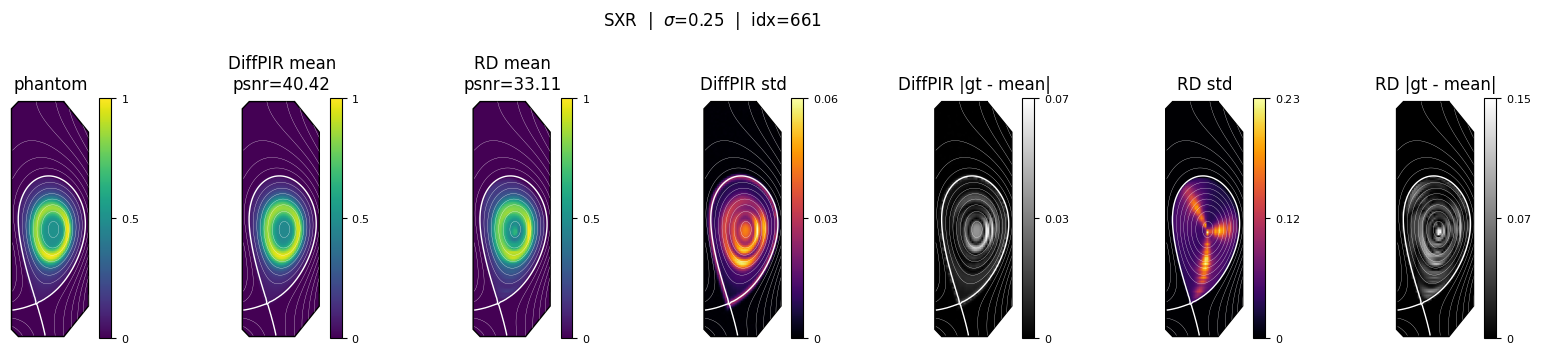

Saved panels and colorbars to results_images/diffpir_vs_rd/sxr_sigma0.25_idx661
  diffpir std vmax = 0.05897   rd std vmax = 0.2325
  diffpir err vmax = 0.06619   rd err vmax = 0.1459


<Figure size 300x300 with 0 Axes>

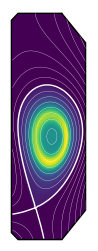

<Figure size 300x300 with 0 Axes>

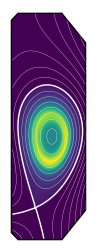

<Figure size 300x300 with 0 Axes>

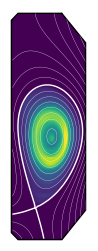

<Figure size 300x300 with 0 Axes>

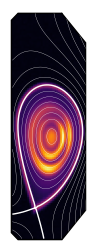

<Figure size 300x300 with 0 Axes>

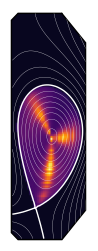

<Figure size 300x300 with 0 Axes>

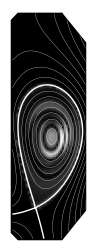

<Figure size 300x300 with 0 Axes>

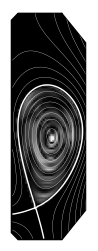

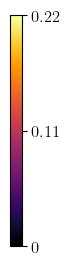

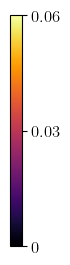

In [3]:
sxr_noise_levels = [0.25]
idx_to_be_plotted = 661 #np.random.randint(0, 1000)#3, 4, 9, 22, 24, 661, 411

for noise in sxr_noise_levels:
    plot_diffpir_vs_rd("sxr", noise, idx_to_be_plotted)
    save_diffpir_vs_rd_panels("sxr", noise, idx_to_be_plotted)

save_cbars = True
if save_cbars:
    # save cbar rd std
    plt.figure(figsize=(2,3))
    plt.rcParams.update({
        "text.usetex": True,
        "font.family": "sans-serif",
    })
    tbp=np.zeros((120,40))
    tbp[0,0]=0.22
    r=plt.imshow(tbp, "inferno")
    plt.gca().set_visible(False)
    cbar=plt.colorbar(r, aspect=20)
    cbar.ax.tick_params(labelsize=12)
    cbar.ax.set_yticks([0,0.11,0.22])
    cbar.ax.set_yticklabels([r"$0$",  r"$0.11$", r"$0.22$"])
    plt.axis("off")
    plt.savefig(EPS_OUT / f"sxr_sigma{noise}_idx{idx_to_be_plotted}" / "cbar_rd_std.eps", format='eps', bbox_inches="tight")
    plt.show()

    # save cbar diffpir std
    plt.figure(figsize=(2,3))
    plt.rcParams.update({
        "text.usetex": True,
        "font.family": "sans-serif",
    })
    tbp=np.zeros((120,40))
    tbp[0,0]=0.06
    r=plt.imshow(tbp, "inferno")
    plt.gca().set_visible(False)
    cbar=plt.colorbar(r, aspect=20)
    cbar.ax.tick_params(labelsize=12)
    cbar.ax.set_yticks([0,0.03,0.06])
    cbar.ax.set_yticklabels([r"$0$",  r"$0.03$", r"$0.06$"])
    plt.axis("off")
    plt.savefig(EPS_OUT / f"sxr_sigma{noise}_idx{idx_to_be_plotted}" / "cbar_diffpir_std.eps", format='eps', bbox_inches="tight")
    plt.show()

## DMPX

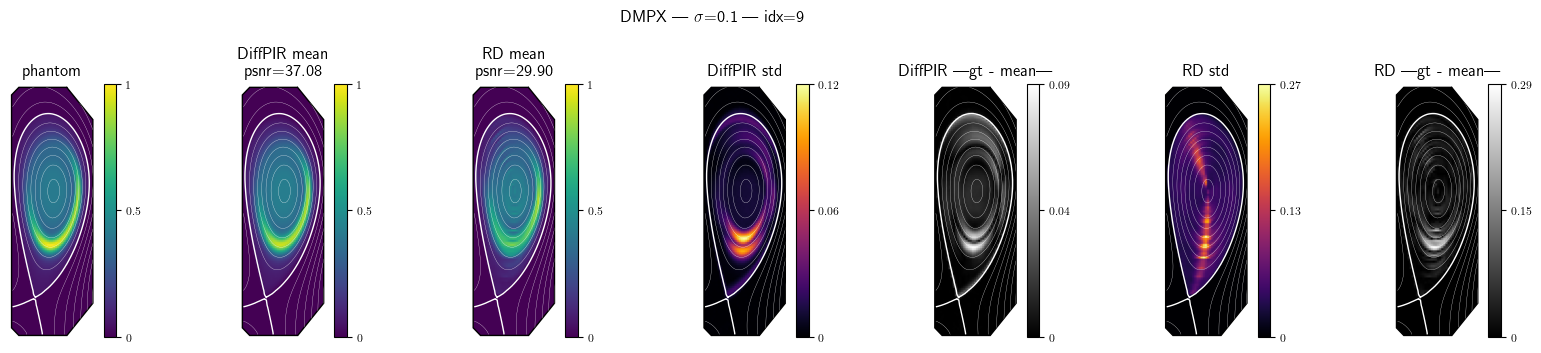

Saved panels and colorbars to results_images/diffpir_vs_rd/dmpx_sigma0.1_idx9
  diffpir std vmax = 0.1208   rd std vmax = 0.2652
  diffpir err vmax = 0.08953   rd err vmax = 0.2919


<Figure size 300x300 with 0 Axes>

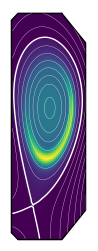

<Figure size 300x300 with 0 Axes>

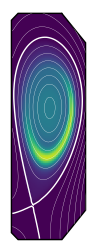

<Figure size 300x300 with 0 Axes>

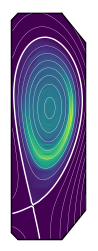

<Figure size 300x300 with 0 Axes>

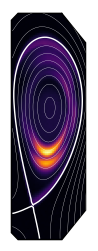

<Figure size 300x300 with 0 Axes>

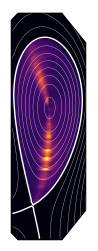

<Figure size 300x300 with 0 Axes>

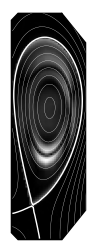

<Figure size 300x300 with 0 Axes>

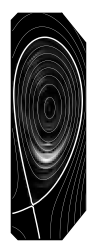

In [4]:
dmpx_noise_levels = [0.1]
idx_to_be_plotted = 9 #3, 4, 9, 22, 24, 50


for noise in dmpx_noise_levels:
    plot_diffpir_vs_rd("dmpx", noise, idx_to_be_plotted)
    save_diffpir_vs_rd_panels("dmpx", noise, idx_to_be_plotted)


save_cbars = False
if save_cbars:
    # save cbar rd std
    plt.figure(figsize=(2,3))
    plt.rcParams.update({
        "text.usetex": True,
        "font.family": "sans-serif",
    })
    tbp=np.zeros((120,40))
    tbp[0,0]=0.27
    r=plt.imshow(tbp, "inferno")
    plt.gca().set_visible(False)
    cbar=plt.colorbar(r, aspect=20)
    cbar.ax.tick_params(labelsize=12)
    cbar.ax.set_yticks([0,0.13,0.27])
    cbar.ax.set_yticklabels([r"$0$",  r"$0.13$", r"$0.26$"])
    plt.axis("off")
    plt.savefig(EPS_OUT / f"dmpx_sigma{noise}_idx{idx_to_be_plotted}" / "cbar_rd_std.eps", format='eps', bbox_inches="tight")
    plt.show()

    # save cbar diffpir std
    plt.figure(figsize=(2,3))
    plt.rcParams.update({
        "text.usetex": True,
        "font.family": "sans-serif",
    })
    tbp=np.zeros((120,40))
    tbp[0,0]=0.12
    r=plt.imshow(tbp, "inferno")
    plt.gca().set_visible(False)
    cbar=plt.colorbar(r, aspect=20)
    cbar.ax.tick_params(labelsize=12)
    cbar.ax.set_yticks([0,0.06,0.12])
    cbar.ax.set_yticklabels([r"$0$",  r"$0.06$", r"$0.12$"])
    plt.axis("off")
    plt.savefig(EPS_OUT / f"dmpx_sigma{noise}_idx{idx_to_be_plotted}" / "cbar_diffpir_std.eps", format='eps', bbox_inches="tight")
    plt.show()



In [5]:
EPS_OUT

PosixPath('results_images/diffpir_vs_rd')

## Pilatus

For Pilatus the relevant DiffPIR-family method is DiffRD (clip=True, with corrected RD params). RD here refers to `pilatus_rdcorrect_ula1e6` — the method shown in the paper's Pilatus table.

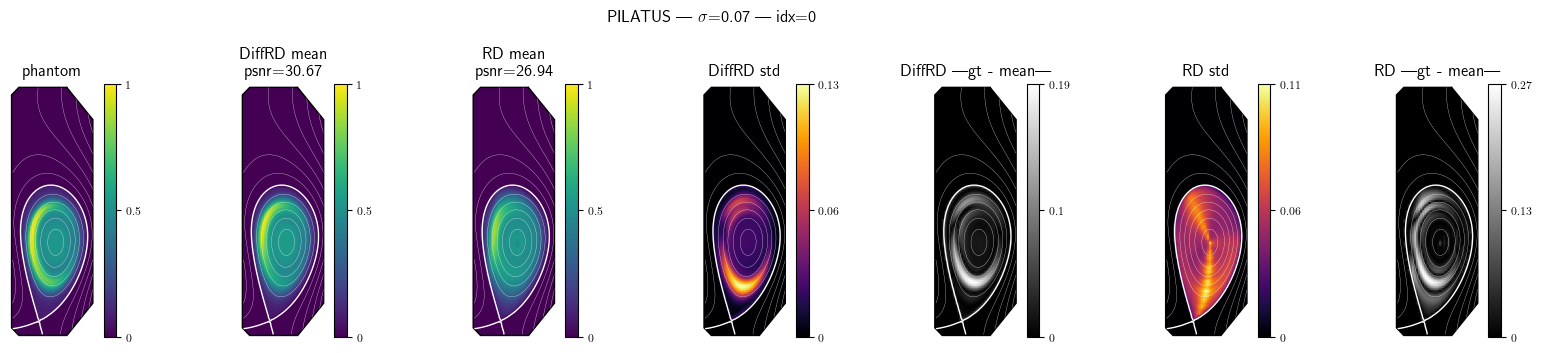

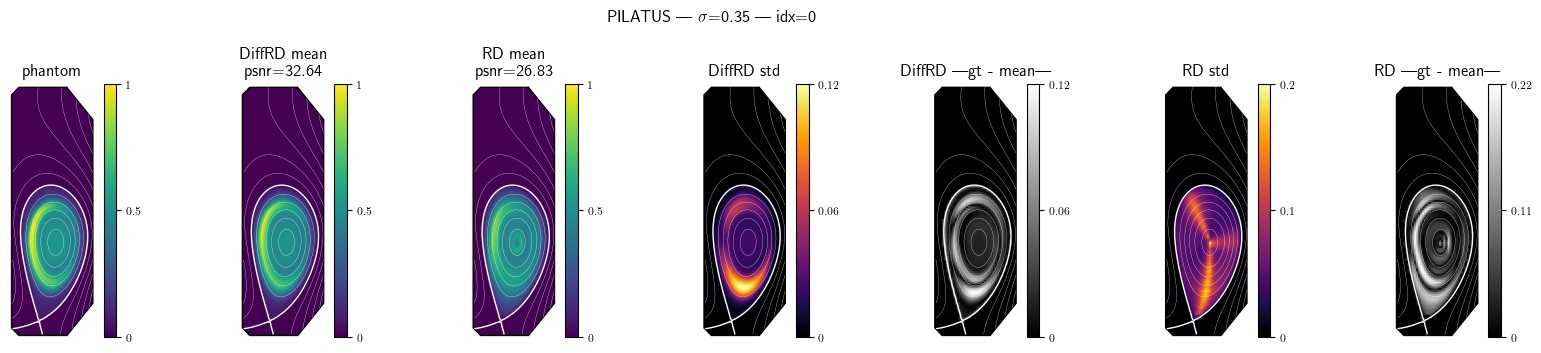

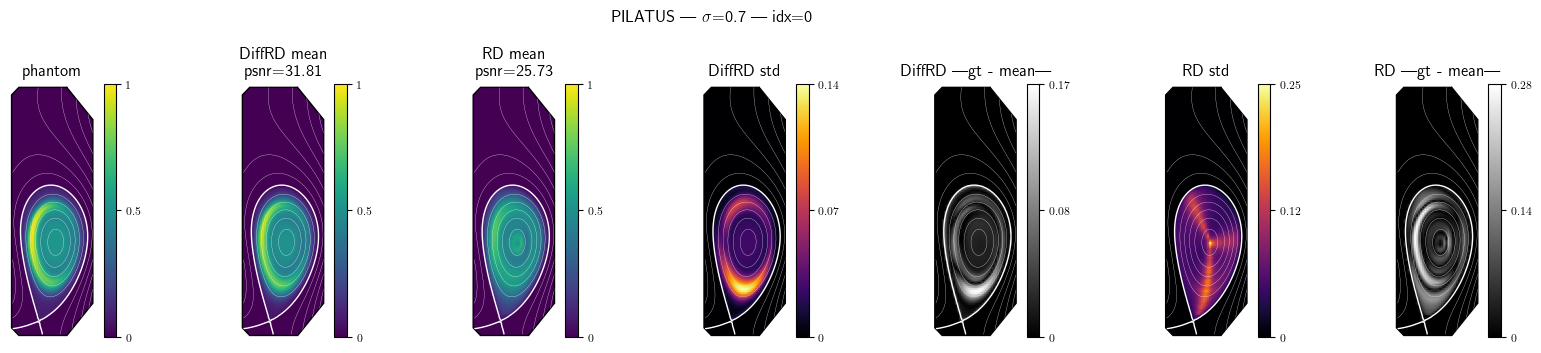

In [6]:
pilatus_noise_levels = [0.07, 0.35, 0.7]
idx_to_be_plotted = 0

for noise in pilatus_noise_levels:
    diffrd_means = np.load(DIFFRD_DIR / f"post_means_pilatus_{noise}_clipTrue_false.npy")[idx_to_be_plotted].reshape(H, W)
    diffrd_stds  = np.load(DIFFRD_DIR / f"post_stds_pilatus_{noise}_clipTrue_false.npy")[idx_to_be_plotted].reshape(H, W)
    rd_means     = np.load(RD_DIR     / f"post_means_pilatus_rdcorrect_ula1e6_{noise}_false.npy")[idx_to_be_plotted].reshape(H, W)
    rd_stds      = np.load(RD_DIR     / f"post_stds_pilatus_rdcorrect_ula1e6_{noise}_false.npy")[idx_to_be_plotted].reshape(H, W)

    diffrd_metrics = pd.read_csv(DIFFRD_DIR / f"metrics_diffusion_pilatus_{noise}_clipTrue_false.csv")
    rd_metrics     = pd.read_csv(RD_DIR     / f"metrics_rd_pilatus_rdcorrect_ula1e6_{noise}_false.csv")

    plot_two_methods(
        gt=GROUND_TRUTH[idx_to_be_plotted], psi=PSI[idx_to_be_plotted],
        m1={"mean": diffrd_means, "std": diffrd_stds}, m1_name="DiffRD",
        m1_psnr=diffrd_metrics["psnr"][idx_to_be_plotted],
        m2={"mean": rd_means,     "std": rd_stds},     m2_name="RD",
        m2_psnr=rd_metrics["psnr_mean"][idx_to_be_plotted],
        suptitle=f"PILATUS  |  $\\sigma$={noise}  |  idx={idx_to_be_plotted}",
    )

### Pilatus — all methods (panel + colorbar EPS export)

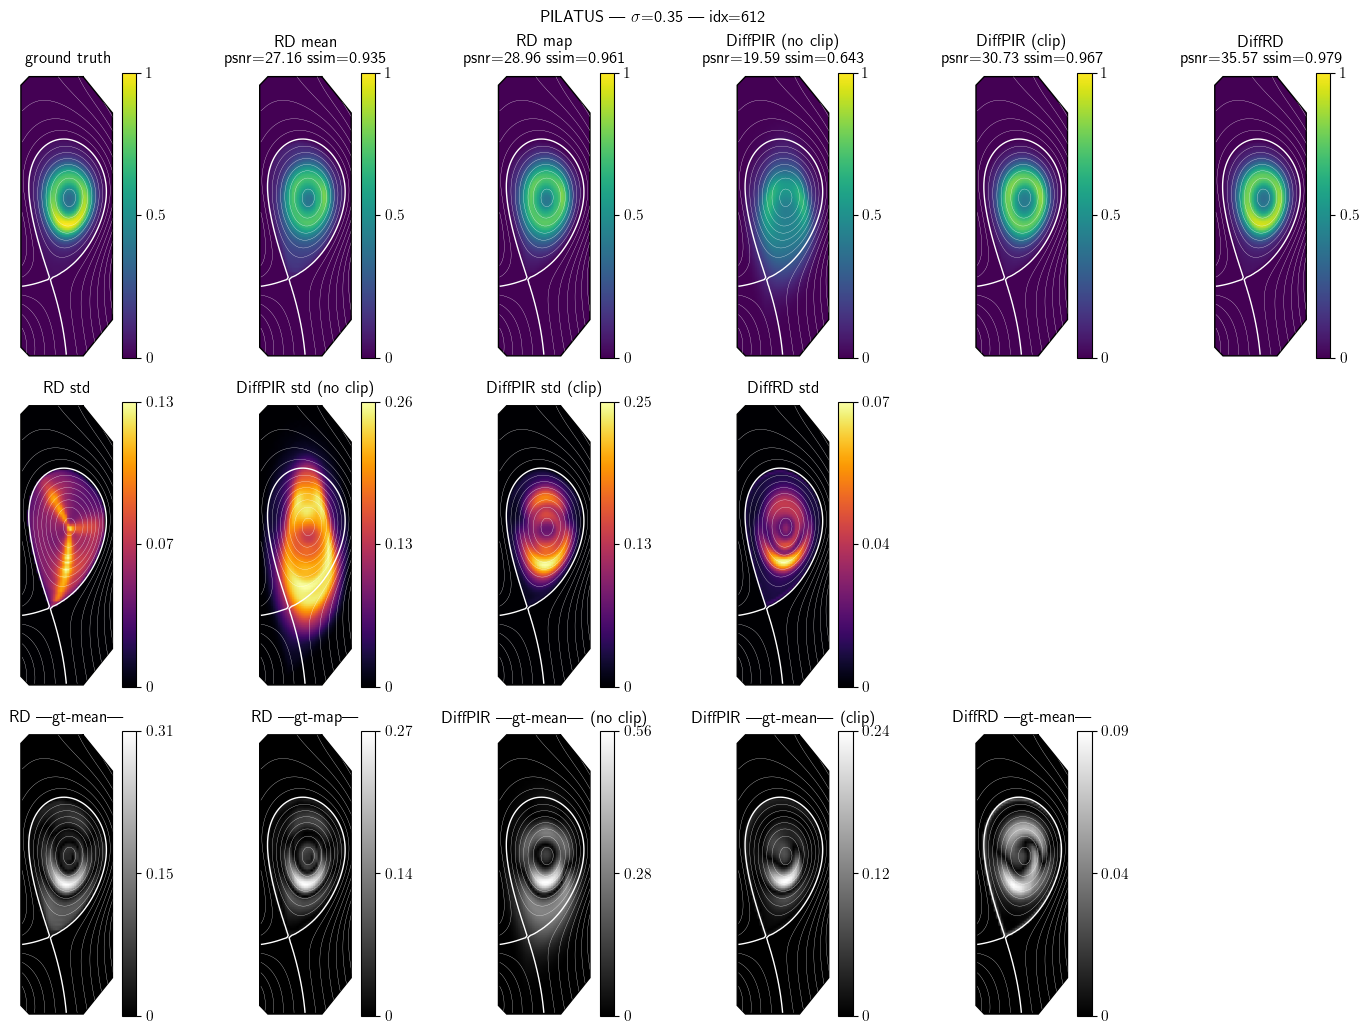

  saved  phantom.eps  (viridis, vmax=0.9969)
  saved  rd_mean_psnr27.16_ssim0.935.eps  (viridis, vmax=0.9969)
  saved  rd_map_psnr28.96_ssim0.961.eps  (viridis, vmax=0.9969)
  saved  diffpir_noclip_mean_psnr19.59_ssim0.643.eps  (viridis, vmax=0.9969)
  saved  diffpir_clip_mean_psnr30.73_ssim0.967.eps  (viridis, vmax=0.9969)
  saved  diffrd_mean_psnr35.57_ssim0.979.eps  (viridis, vmax=0.9969)
  saved  rd_std.eps  (inferno, auto-scale)
  saved  diffpir_noclip_std.eps  (inferno, auto-scale)
  saved  diffpir_clip_std.eps  (inferno, auto-scale)
  saved  diffrd_std.eps  (inferno, auto-scale)


/tmp/ipykernel_900864/705921310.py:155: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(3,3))


  saved  rd_mean_err.eps  (gray, auto-scale)
  saved  rd_map_err.eps  (gray, auto-scale)
  saved  diffpir_noclip_err.eps  (gray, auto-scale)
  saved  diffpir_clip_err.eps  (gray, auto-scale)
  saved  diffrd_err.eps  (gray, auto-scale)


<Figure size 300x300 with 0 Axes>

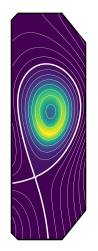

<Figure size 300x300 with 0 Axes>

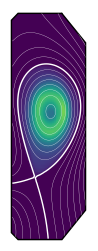

<Figure size 300x300 with 0 Axes>

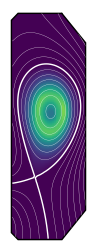

<Figure size 300x300 with 0 Axes>

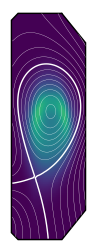

<Figure size 300x300 with 0 Axes>

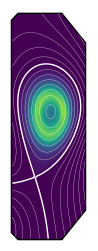

<Figure size 300x300 with 0 Axes>

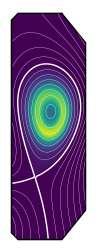

<Figure size 300x300 with 0 Axes>

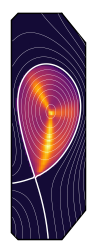

<Figure size 300x300 with 0 Axes>

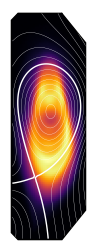

<Figure size 300x300 with 0 Axes>

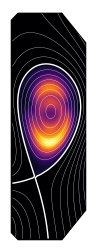

<Figure size 300x300 with 0 Axes>

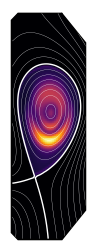

<Figure size 300x300 with 0 Axes>

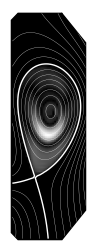

<Figure size 300x300 with 0 Axes>

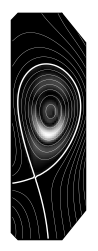

<Figure size 300x300 with 0 Axes>

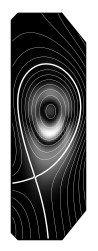

<Figure size 300x300 with 0 Axes>

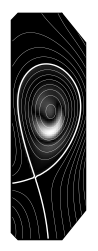

<Figure size 300x300 with 0 Axes>

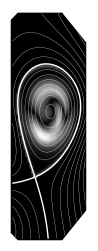

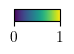

  saved  cbar_mean.eps  (viridis, vmax=0.9969)


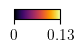

  saved  cbar_rd_std.eps  (inferno, vmax=0.1348)


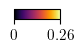

  saved  cbar_diffpir_noclip_std.eps  (inferno, vmax=0.2625)


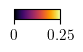

  saved  cbar_diffpir_clip_std.eps  (inferno, vmax=0.2508)


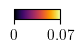

  saved  cbar_diffrd_std.eps  (inferno, vmax=0.07488)


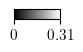

  saved  cbar_rd_mean_err.eps  (gray, vmax=0.3095)


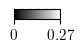

  saved  cbar_rd_map_err.eps  (gray, vmax=0.2725)


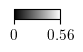

  saved  cbar_diffpir_noclip_err.eps  (gray, vmax=0.5573)


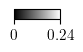

  saved  cbar_diffpir_clip_err.eps  (gray, vmax=0.2397)


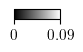

  saved  cbar_diffrd_err.eps  (gray, vmax=0.08864)

All files written to results_images/pilatus/pilatus_all_sigma0.35_idx612


In [ ]:
pilatus_noise = 0.35
idx           = 612 # 68-0.07,52-0.7, 612-0.35 np.random.randint(0,1000)
# 3/4
# 28 : rdd beats diffusion and rd
#122->small ring around center, 2->fine right asymmetry,
# 9->upper left asymm works super well, 12->lower asymm works bad,
# 30->blob centered, 29->big fat ring
# 31 -> bottom asymm works bad, 41-> top asym works well
# 47->left asym works quite well, 49->left asym plasma very high in vessel works well
# 87-> right asym works well
save_panels   = False
save_cbars    = False
cbar_fontsize = 11

gt        = GROUND_TRUTH[idx]
psi       = PSI[idx]
vmax_mean = float(gt.max())

# go to parent direcotry of EPS_OUT then descend to "pilatus"
PILATUS_RES_DIR = EPS_OUT.parent / "pilatus"
PILATUS_RES_DIR.mkdir(parents=True, exist_ok=True)

# ---------- load data ----------
rd_means  = np.load(RD_DIR     / f"post_means_pilatus_rdcorrect_ula1e6_{pilatus_noise}_false.npy")[idx].reshape(H, W)
rd_maps   = np.load(RD_DIR     / f"maps_pilatus_rdcorrect_ula1e6_{pilatus_noise}_false.npy")[idx].reshape(H, W)
rd_stds   = np.load(RD_DIR     / f"post_stds_pilatus_rdcorrect_ula1e6_{pilatus_noise}_false.npy")[idx].reshape(H, W)

dn_means  = np.load(DIFF_DIR   / f"post_means_pilatus_{pilatus_noise}_clipFalse_false.npy")[idx].reshape(H, W)
dn_stds   = np.load(DIFF_DIR   / f"post_stds_pilatus_{pilatus_noise}_clipFalse_false.npy")[idx].reshape(H, W)

dc_means  = np.load(DIFF_DIR   / f"post_means_pilatus_{pilatus_noise}_clipTrue_false.npy")[idx].reshape(H, W)
dc_stds   = np.load(DIFF_DIR   / f"post_stds_pilatus_{pilatus_noise}_clipTrue_false.npy")[idx].reshape(H, W)

drd_means = np.load(DIFFRD_DIR / f"post_means_pilatus_{pilatus_noise}_clipTrue_false.npy")[idx].reshape(H, W)
drd_stds  = np.load(DIFFRD_DIR / f"post_stds_pilatus_{pilatus_noise}_clipTrue_false.npy")[idx].reshape(H, W)

# ---------- load metrics ----------
rd_metrics  = pd.read_csv(RD_DIR     / f"metrics_rd_pilatus_rdcorrect_ula1e6_{pilatus_noise}_false.csv")
dn_metrics  = pd.read_csv(DIFF_DIR   / f"metrics_diffusion_pilatus_{pilatus_noise}_clipFalse_false.csv")
dc_metrics  = pd.read_csv(DIFF_DIR   / f"metrics_diffusion_pilatus_{pilatus_noise}_clipTrue_false.csv")
drd_metrics = pd.read_csv(DIFFRD_DIR / f"metrics_diffusion_pilatus_{pilatus_noise}_clipTrue_false.csv")

rd_psnr,     rd_ssim     = float(rd_metrics["psnr_mean"][idx]),  float(rd_metrics["ssim_mean"][idx])
rd_map_psnr, rd_map_ssim = float(rd_metrics["psnr_map"][idx]),   float(rd_metrics["ssim_map"][idx])
dn_psnr,     dn_ssim     = float(dn_metrics["psnr"][idx]),       float(dn_metrics["ssim"][idx])
dc_psnr,     dc_ssim     = float(dc_metrics["psnr"][idx]),       float(dc_metrics["ssim"][idx])
drd_psnr,    drd_ssim    = float(drd_metrics["psnr"][idx]),      float(drd_metrics["ssim"][idx])

# ---------- compute errors ----------
rd_err   = np.abs(gt - rd_means)
rdm_err  = np.abs(gt - rd_maps)
dn_err   = np.abs(gt - dn_means)
dc_err   = np.abs(gt - dc_means)
drd_err  = np.abs(gt - drd_means)

# ---------- panel groups: (img, display_title, save_filename_stem) ----------
mean_panels = [
    (gt,        "ground truth",
     "phantom"),
    (rd_means,  f"RD mean\npsnr={rd_psnr:.2f}  ssim={rd_ssim:.3f}",
     f"rd_mean_psnr{rd_psnr:.2f}_ssim{rd_ssim:.3f}"),
    (rd_maps,   f"RD map\npsnr={rd_map_psnr:.2f}  ssim={rd_map_ssim:.3f}",
     f"rd_map_psnr{rd_map_psnr:.2f}_ssim{rd_map_ssim:.3f}"),
    (dn_means,  f"DiffPIR (no clip)\npsnr={dn_psnr:.2f}  ssim={dn_ssim:.3f}",
     f"diffpir_noclip_mean_psnr{dn_psnr:.2f}_ssim{dn_ssim:.3f}"),
    (dc_means,  f"DiffPIR (clip)\npsnr={dc_psnr:.2f}  ssim={dc_ssim:.3f}",
     f"diffpir_clip_mean_psnr{dc_psnr:.2f}_ssim{dc_ssim:.3f}"),
    (drd_means, f"DiffRD\npsnr={drd_psnr:.2f}  ssim={drd_ssim:.3f}",
     f"diffrd_mean_psnr{drd_psnr:.2f}_ssim{drd_ssim:.3f}"),
]
std_panels = [
    (rd_stds,  "RD std",                "rd_std"),
    (dn_stds,  "DiffPIR std (no clip)", "diffpir_noclip_std"),
    (dc_stds,  "DiffPIR std (clip)",    "diffpir_clip_std"),
    (drd_stds, "DiffRD std",            "diffrd_std"),
]
err_panels = [
    (rd_err,  "RD |gt-mean|",                "rd_mean_err"),
    (rdm_err, "RD |gt-map|",                 "rd_map_err"),
    (dn_err,  "DiffPIR |gt-mean| (no clip)", "diffpir_noclip_err"),
    (dc_err,  "DiffPIR |gt-mean| (clip)",    "diffpir_clip_err"),
    (drd_err, "DiffRD |gt-mean|",            "diffrd_err"),
]

# ---------- display (3 rows: viridis / inferno std / gray error) — vertical cbars ----------
vir_t, vir_l = _resolve(None, None, vmax_mean)

fig, axes = plt.subplots(3, 6, figsize=(2.4 * 6, 3.5 * 3))

for i, (img, title, _) in enumerate(mean_panels):
    _panel(axes[0, i], img, psi, "viridis", title, vmax=vmax_mean)
    _attach_cbar(fig, axes[0, i], "viridis", vmax_mean, vir_t, vir_l, cbar_fontsize)

for i, (img, title, _) in enumerate(std_panels):
    _sv = float(img.max()); _st, _sl = _resolve(None, None, _sv)
    _panel(axes[1, i], img, psi, "inferno", title)
    _attach_cbar(fig, axes[1, i], "inferno", _sv, _st, _sl, cbar_fontsize)
for i in range(len(std_panels), 6):
    axes[1, i].set_visible(False)

for i, (img, title, _) in enumerate(err_panels):
    _ev = float(img.max()); _et, _el = _resolve(None, None, _ev)
    _panel(axes[2, i], img, psi, "gray", title)
    _attach_cbar(fig, axes[2, i], "gray", _ev, _et, _el, cbar_fontsize)
axes[2, 5].set_visible(False)

fig.suptitle(f"PILATUS  |  $\\sigma$={pilatus_noise}  |  idx={idx}")
plt.tight_layout()
plt.show()

# ---------- output directory ----------
out = PILATUS_RES_DIR / f"pilatus_all_sigma{pilatus_noise}_idx{idx}"
out.mkdir(parents=True, exist_ok=True)

# ---------- save panels ----------
if save_panels:
    for img, _, name in mean_panels:
        _save_panel(img, psi, "viridis", out / f"{name}.eps", vmin=0, vmax=vmax_mean)
        print(f"  saved  {name}.eps  (viridis, vmax={vmax_mean:.4g})")
    for img, _, name in std_panels:
        _save_panel(img, psi, "inferno", out / f"{name}.eps", vmin=0, vmax=None)
        print(f"  saved  {name}.eps  (inferno, auto-scale)")
    for img, _, name in err_panels:
        _save_panel(img, psi, "gray", out / f"{name}.eps", vmin=0, vmax=None)
        print(f"  saved  {name}.eps  (gray, auto-scale)")

# ---------- save colorbars — horizontal, only min/max ticks ----------
if save_cbars:
    plt.rcParams.update({"text.usetex": True, "font.family": "sans-serif"})

    # viridis — shared, vmax = gt.max()
    tbp = np.zeros((H, W)); tbp[0, 0] = vmax_mean
    plt.figure(figsize=(2, 3))
    r = plt.imshow(tbp, "viridis")
    plt.gca().set_visible(False)
    cbar = plt.colorbar(r, orientation="horizontal", aspect=4, shrink=0.3)
    cbar.ax.tick_params(labelsize=cbar_fontsize)
    cbar.ax.set_xticks([0, vmax_mean])
    cbar.ax.set_xticklabels([r"$0$", _fmt_tick(vmax_mean)])
    plt.axis("off")
    plt.savefig(out / "cbar_mean.eps", format="eps", bbox_inches="tight")
    plt.show()
    print(f"  saved  cbar_mean.eps  (viridis, vmax={vmax_mean:.4g})")

    # inferno — one per std panel
    for img, _, name in std_panels:
        _sv = float(img.max())
        tbp = np.zeros((H, W)); tbp[0, 0] = _sv
        plt.figure(figsize=(2, 3))
        r = plt.imshow(tbp, "inferno")
        plt.gca().set_visible(False)
        cbar = plt.colorbar(r, orientation="horizontal", aspect=5, shrink=0.3)
        cbar.ax.tick_params(labelsize=cbar_fontsize)
        cbar.ax.set_xticks([0, _sv])
        cbar.ax.set_xticklabels([r"$0$", _fmt_tick(_sv)])
        plt.axis("off")
        plt.savefig(out / f"cbar_{name}.eps", format="eps", bbox_inches="tight")
        plt.show()
        print(f"  saved  cbar_{name}.eps  (inferno, vmax={_sv:.4g})")

    # gray — one per error panel
    for img, _, name in err_panels:
        _ev = float(img.max())
        tbp = np.zeros((H, W)); tbp[0, 0] = _ev
        plt.figure(figsize=(2, 3))
        r = plt.imshow(tbp, "gray")
        plt.gca().set_visible(False)
        cbar = plt.colorbar(r, orientation="horizontal", aspect=5, shrink=0.3)
        cbar.ax.tick_params(labelsize=cbar_fontsize)
        cbar.ax.set_xticks([0, _ev])
        cbar.ax.set_xticklabels([r"$0$", _fmt_tick(_ev)])
        plt.axis("off")
        plt.savefig(out / f"cbar_{name}.eps", format="eps", bbox_inches="tight")
        plt.show()
        print(f"  saved  cbar_{name}.eps  (gray, vmax={_ev:.4g})")

print(f"\nAll files written to {out}")

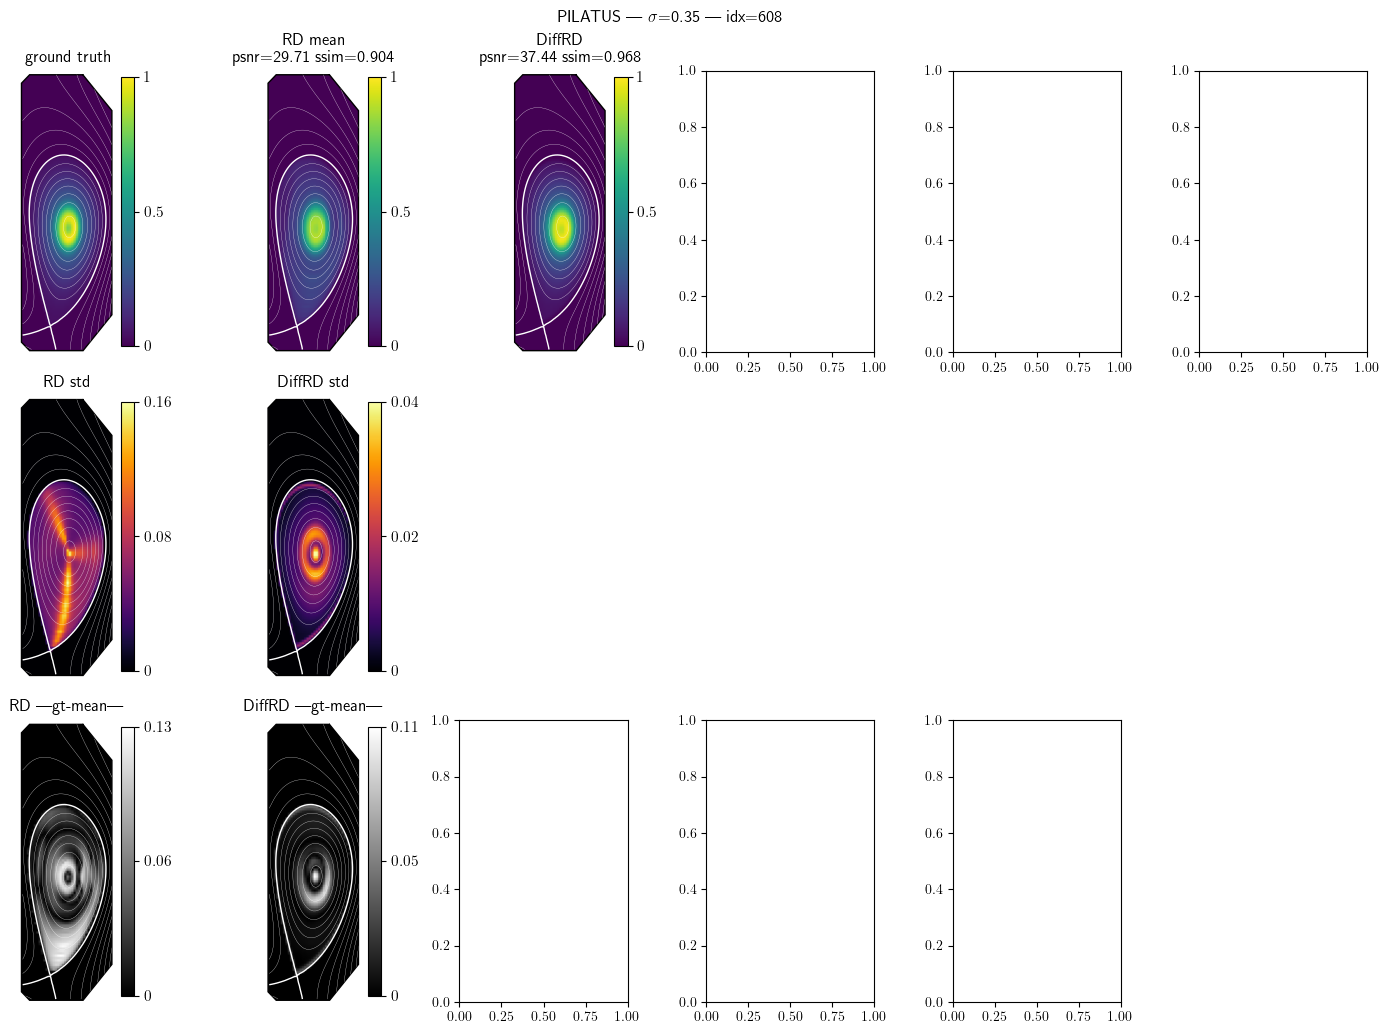

  saved  phantom.eps  (viridis, vmax=0.9989)
  saved  rd_mean_psnr29.71_ssim0.904.eps  (viridis, vmax=0.9989)
  saved  diffrd_mean_psnr37.44_ssim0.968.eps  (viridis, vmax=0.9989)
  saved  rd_std.eps  (inferno, auto-scale)


In [ ]:
pilatus_noise = 0.35
idx           = 608 #np.random.randint(0,1000)
# 3/4
# 28 : rdd beats diffusion and rd
#122->small ring around center, 2->fine right asymmetry,
# 9->upper left asymm works super well, 12->lower asymm works bad,
# 30->blob centered, 29->big fat ring
# 31 -> bottom asymm works bad, 41-> top asym works well
# 47->left asym works quite well, 49->left asym plasma very high in vessel works well
# 87-> right asym works well
save_panels   = True
save_cbars    = False
cbar_fontsize = 11

gt        = GROUND_TRUTH[idx]
psi       = PSI[idx]
vmax_mean = float(gt.max())

# go to parent direcotry of EPS_OUT then descend to "pilatus"
PILATUS_RES_DIR = EPS_OUT.parent / "pilatus"
if save_panels and save_cbars:
    PILATUS_RES_DIR.mkdir(parents=True, exist_ok=True)

# ---------- load data ----------
rd_means  = np.load(RD_DIR     / f"post_means_pilatus_rdcorrect_ula1e6_{pilatus_noise}_false.npy")[idx].reshape(H, W)
rd_maps   = np.load(RD_DIR     / f"maps_pilatus_rdcorrect_ula1e6_{pilatus_noise}_false.npy")[idx].reshape(H, W)
rd_stds   = np.load(RD_DIR     / f"post_stds_pilatus_rdcorrect_ula1e6_{pilatus_noise}_false.npy")[idx].reshape(H, W)

drd_means = np.load(DIFFRD_DIR / f"post_means_pilatus_{pilatus_noise}_clipTrue_false.npy")[idx].reshape(H, W)
drd_stds  = np.load(DIFFRD_DIR / f"post_stds_pilatus_{pilatus_noise}_clipTrue_false.npy")[idx].reshape(H, W)

# ---------- load metrics ----------
rd_metrics  = pd.read_csv(RD_DIR     / f"metrics_rd_pilatus_rdcorrect_ula1e6_{pilatus_noise}_false.csv")
dn_metrics  = pd.read_csv(DIFF_DIR   / f"metrics_diffusion_pilatus_{pilatus_noise}_clipFalse_false.csv")
dc_metrics  = pd.read_csv(DIFF_DIR   / f"metrics_diffusion_pilatus_{pilatus_noise}_clipTrue_false.csv")
drd_metrics = pd.read_csv(DIFFRD_DIR / f"metrics_diffusion_pilatus_{pilatus_noise}_clipTrue_false.csv")

rd_psnr,     rd_ssim     = float(rd_metrics["psnr_mean"][idx]),  float(rd_metrics["ssim_mean"][idx])
rd_map_psnr, rd_map_ssim = float(rd_metrics["psnr_map"][idx]),   float(rd_metrics["ssim_map"][idx])
dn_psnr,     dn_ssim     = float(dn_metrics["psnr"][idx]),       float(dn_metrics["ssim"][idx])
dc_psnr,     dc_ssim     = float(dc_metrics["psnr"][idx]),       float(dc_metrics["ssim"][idx])
drd_psnr,    drd_ssim    = float(drd_metrics["psnr"][idx]),      float(drd_metrics["ssim"][idx])

# ---------- compute errors ----------
rd_err   = np.abs(gt - rd_means)
rdm_err  = np.abs(gt - rd_maps)
dn_err   = np.abs(gt - dn_means)
dc_err   = np.abs(gt - dc_means)
drd_err  = np.abs(gt - drd_means)

# ---------- panel groups: (img, display_title, save_filename_stem) ----------
mean_panels = [
    (gt,        "ground truth",
     "phantom"),
    (rd_means,  f"RD mean\npsnr={rd_psnr:.2f}  ssim={rd_ssim:.3f}",
     f"rd_mean_psnr{rd_psnr:.2f}_ssim{rd_ssim:.3f}"),
    (drd_means, f"DiffRD\npsnr={drd_psnr:.2f}  ssim={drd_ssim:.3f}",
     f"diffrd_mean_psnr{drd_psnr:.2f}_ssim{drd_ssim:.3f}"),
]
std_panels = [
    (rd_stds,  "RD std",                "rd_std"),
    (drd_stds, "DiffRD std",            "diffrd_std"),
]
err_panels = [
    (rd_err,  "RD |gt-mean|",                "rd_mean_err"),
    (drd_err, "DiffRD |gt-mean|",            "diffrd_err"),
]

# ---------- display (3 rows: viridis / inferno std / gray error) — vertical cbars ----------
vir_t, vir_l = _resolve(None, None, vmax_mean)

fig, axes = plt.subplots(3, 6, figsize=(2.4 * 6, 3.5 * 3))

for i, (img, title, _) in enumerate(mean_panels):
    _panel(axes[0, i], img, psi, "viridis", title, vmax=vmax_mean)
    _attach_cbar(fig, axes[0, i], "viridis", vmax_mean, vir_t, vir_l, cbar_fontsize)

for i, (img, title, _) in enumerate(std_panels):
    _sv = float(img.max()); _st, _sl = _resolve(None, None, _sv)
    _panel(axes[1, i], img, psi, "inferno", title)
    _attach_cbar(fig, axes[1, i], "inferno", _sv, _st, _sl, cbar_fontsize)
for i in range(len(std_panels), 6):
    axes[1, i].set_visible(False)

for i, (img, title, _) in enumerate(err_panels):
    _ev = float(img.max()); _et, _el = _resolve(None, None, _ev)
    _panel(axes[2, i], img, psi, "gray", title)
    _attach_cbar(fig, axes[2, i], "gray", _ev, _et, _el, cbar_fontsize)
axes[2, 5].set_visible(False)

fig.suptitle(f"PILATUS  |  $\\sigma$={pilatus_noise}  |  idx={idx}")
plt.tight_layout()
plt.show()

# ---------- output directory ----------
out = PILATUS_RES_DIR / f"pilatus_all_sigma{pilatus_noise}_idx{idx}"
out.mkdir(parents=True, exist_ok=True)

# ---------- save panels ----------
if save_panels:
    for img, _, name in mean_panels:
        _save_panel(img, psi, "viridis", out / f"{name}.eps", vmin=0, vmax=vmax_mean)
        print(f"  saved  {name}.eps  (viridis, vmax={vmax_mean:.4g})")
    for img, _, name in std_panels:
        _save_panel(img, psi, "inferno", out / f"{name}.eps", vmin=0, vmax=None, lcfs_width=1, lwidth=0.04, levels=5)
        print(f"  saved  {name}.eps  (inferno, auto-scale)")
    for img, _, name in err_panels:
        _save_panel(img, psi, "gray", out / f"{name}.eps", vmin=0, vmax=None, lcfs_width=1, lwidth=0.04, levels=5)
        print(f"  saved  {name}.eps  (gray, auto-scale)")

# ---------- save colorbars — horizontal, only min/max ticks ----------
if save_cbars:
    plt.rcParams.update({"text.usetex": True, "font.family": "sans-serif"})

    # viridis — shared, vmax = gt.max()
    tbp = np.zeros((H, W)); tbp[0, 0] = vmax_mean
    plt.figure(figsize=(2, 3))
    r = plt.imshow(tbp, "viridis")
    plt.gca().set_visible(False)
    cbar = plt.colorbar(r, orientation="horizontal", aspect=4, shrink=0.3)
    cbar.ax.tick_params(labelsize=cbar_fontsize)
    cbar.ax.set_xticks([0, vmax_mean])
    cbar.ax.set_xticklabels([r"$0$", _fmt_tick(vmax_mean)])
    plt.axis("off")
    plt.savefig(out / "cbar_mean.eps", format="eps", bbox_inches="tight")
    plt.show()
    print(f"  saved  cbar_mean.eps  (viridis, vmax={vmax_mean:.4g})")

    # inferno — one per std panel
    for img, _, name in std_panels:
        _sv = float(img.max())
        tbp = np.zeros((H, W)); tbp[0, 0] = _sv
        plt.figure(figsize=(2, 3))
        r = plt.imshow(tbp, "inferno")
        plt.gca().set_visible(False)
        cbar = plt.colorbar(r, orientation="horizontal", aspect=5, shrink=0.3)
        cbar.ax.tick_params(labelsize=cbar_fontsize)
        cbar.ax.set_xticks([0, _sv])
        cbar.ax.set_xticklabels([r"$0$", _fmt_tick(_sv)])
        plt.axis("off")
        plt.savefig(out / f"cbar_{name}.eps", format="eps", bbox_inches="tight")
        plt.show()
        print(f"  saved  cbar_{name}.eps  (inferno, vmax={_sv:.4g})")

    # gray — one per error panel
    for img, _, name in err_panels:
        _ev = float(img.max())
        tbp = np.zeros((H, W)); tbp[0, 0] = _ev
        plt.figure(figsize=(2, 3))
        r = plt.imshow(tbp, "gray")
        plt.gca().set_visible(False)
        cbar = plt.colorbar(r, orientation="horizontal", aspect=5, shrink=0.3)
        cbar.ax.tick_params(labelsize=cbar_fontsize)
        cbar.ax.set_xticks([0, _ev])
        cbar.ax.set_xticklabels([r"$0$", _fmt_tick(_ev)])
        plt.axis("off")
        plt.savefig(out / f"cbar_{name}.eps", format="eps", bbox_inches="tight")
        plt.show()
        print(f"  saved  cbar_{name}.eps  (gray, vmax={_ev:.4g})")

print(f"\nAll files written to {out}")